# Observed Stellar Spectrum Acquisition and Preparation

## Objective

The goal of this notebook is to select and prepare a high-quality observed stellar spectrum for Hβ line profile analysis.

The selected spectrum must satisfy:

- Solar-type star (F5-K2 V)
- SNR ≥ 50 near Hβ
- Suitable wavelength coverage around 4861 Å
- Publicly reproducible data source

# 1. Target Star Selection

## Selected Star

Star Name: 18 Scorpii

HD Number: HD 146233

Spectral Type: G2 V

Luminosity Class: Main Sequence (V)


## Reason for Selection

18 Scorpii is a well-studied solar twin star with atmospheric properties similar to the Sun.

It satisfies the project requirement of selecting a solar-type star (F5–K2, luminosity class V).

The star is suitable for Hβ line profile analysis because the Balmer line responds strongly to stellar effective temperature and surface gravity.

# 2. Observed Spectrum Archive Selection

The observed spectrum will be obtained from the ELODIE spectral library.

ELODIE is selected because:

- Spectra are already reduced.
- Spectra are wavelength calibrated.
- Spectra are radial velocity corrected.
- Spectra are normalized.
- The resolution is suitable for stellar atmospheric analysis.

Archive:

ELODIE Spectral Library

Archive URL:
http://atlas.obs-hp.fr/elodie/

Reference:

Prugniel & Soubiran (2001)

# 3. Observed Spectrum Identification

## Target Star

Star Name:

18 Scorpii


HD Catalogue Number:

HD 146233


Spectral Type:

G2 V


## Archive Information

Archive:

ELODIE Stellar Library


Dataset:

20000327


Spectrum Identifier:

0030


File Name:

elodie_20000327_0030


Signal-to-Noise Ratio:

S/N = 237


The spectrum satisfies the project requirement of SNR ≥ 50 in the blue optical region.

The downloaded spectrum is a reduced, wavelength-calibrated stellar spectrum suitable for Hβ line profile analysis.

# 4. Inspecting the Observed Spectrum FITS File

The downloaded ELODIE spectrum is stored in FITS format.

The FITS file header contains important metadata including:

- Instrument information
- Wavelength calibration
- Spectral resolution
- Observation details

The file will be inspected using `astropy.io.fits`.

In [89]:
from astropy.io import fits

file_path = "../data/observed/ELODIE/elodie_20000327_0030.fits"

hdul = fits.open(file_path)

hdul.info()

Filename: ../data/observed/ELODIE/elodie_20000327_0030.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  INTENSITY     1 PrimaryHDU     109   (56000,)   float32   
  1  FCANOR        1 BinTableHDU     25   147R x 1C   [1E]   
  2  NOISE         1 ImageHDU       106   (56000,)   float32   


In [90]:
header = hdul[0].header

header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / No.Bits per pixel                              
NAXIS   =                    1 / number of data axes                            
NAXIS1  =                56000 / length of data axis 1                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics',

In [91]:
for key in header.keys():
    print(key, "=", header[key])

SIMPLE = True
BITPIX = -32
NAXIS = 1
NAXIS1 = 56000
EXTEND = True
COMMENT =   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
  FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
  FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
  FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
= '*       '           / COMMENT
        The ELODIE archive (OHP)
 Note: The telescope position (POS1,POS2) and the catalogue information
(NOOBETn)
    may not be accurate. Please use instead the designation from keyword
 (OBJECT)
COMMENT =   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 37

# 5. Spectrum Properties

The important properties of the observed ELODIE spectrum were extracted from the FITS header.

## Wavelength Coverage

The spectrum contains 56000 pixels.

The wavelength calibration is:

Starting wavelength:
4000 Å

Pixel wavelength increment:
0.05 Å/pixel

The wavelength coverage is approximately:

4000 Å – 6800 Å


## Signal-to-Noise Ratio

The FITS header provides:

S/N = 236.8 per pixel at 550 nm.

This satisfies the project requirement:

SNR ≥ 50 near the blue optical region.


## Spectral Resolution

The wavelength resolution from the header is:

Δλ ≈ 0.132 Å

At the Hβ wavelength:

λ = 4861 Å

The resolving power is:

R = λ/Δλ

R ≈ 36,800

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Extract flux
flux = hdul[0].data

# Create wavelength array
header = hdul[0].header

start_wave = header["CRVAL1"]
step = header["CDELT1"]
pixels = header["NAXIS1"]

wavelength = start_wave + np.arange(pixels) * step

print("Wavelength range:")
print(wavelength[0], wavelength[-1])

print("Flux length:")
print(len(flux))

Wavelength range:
4000.0 6799.9500391993
Flux length:
56000


## 5.1 Full Observed Spectrum Visualization

The wavelength and flux arrays were used to visualize the complete observed spectrum of HD 146233.

The plot shows:

- The observed stellar flux across the full ELODIE wavelength range (4000–6800 Å).
- The position of the Hβ absorption line at 4861 Å marked with a vertical dashed line.

This visualization verifies that the downloaded spectrum is correctly loaded and identifies the spectral region used for further analysis.

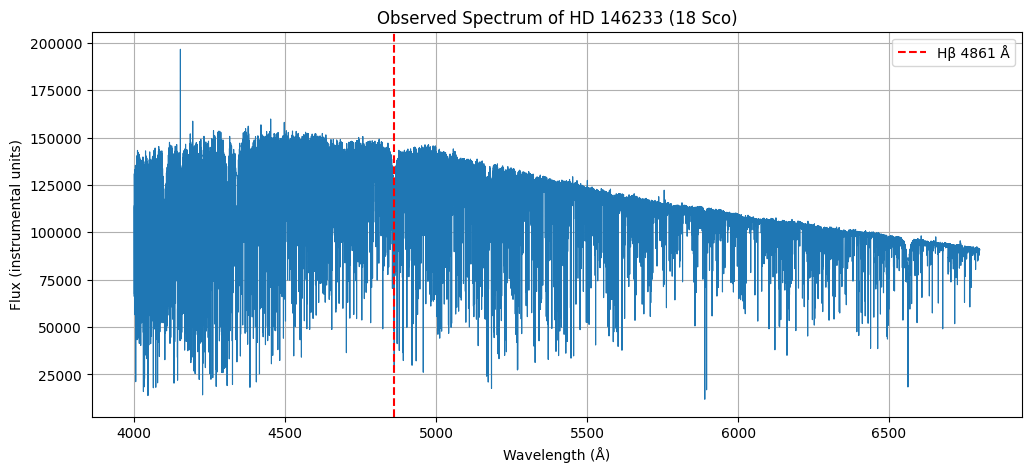

In [93]:
plt.figure(figsize=(12,5))

plt.plot(wavelength, flux, linewidth=0.8)

# Mark H beta line
plt.axvline(4861, color="red", linestyle="--", label="Hβ 4861 Å")

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (instrumental units)")

plt.title("Observed Spectrum of HD 146233 (18 Sco)")

plt.legend()

plt.grid(True)

plt.show()

## 6. Hβ Spectral Region Extraction

The Hβ absorption line at 4861 Å is the primary spectral feature used for stellar atmospheric parameter determination.

A wavelength window of 4800–4900 Å was selected to isolate the Hβ line while including enough nearby continuum regions for normalization.

The extracted region will be used for continuum normalization and subsequent line profile fitting.

In [94]:
# Define Hβ wavelength region

hb_center = 4861.0

region_mask = (wavelength >= 4800) & (wavelength <= 4900)

hb_wavelength = wavelength[region_mask]
hb_flux = flux[region_mask]

print("Hβ wavelength range:")
print(hb_wavelength[0], hb_wavelength[-1])

print("Number of pixels:")
print(len(hb_flux))

Hβ wavelength range:
4800.0000112 4899.9500125993
Number of pixels:
2000


### Hβ Region Visualization

The extracted Hβ region of the observed spectrum is shown below.
The vertical dashed line indicates the theoretical central wavelength of the
Hβ absorption line (4861 Å).

This visualization confirms that the selected wavelength window contains the
Balmer Hβ absorption feature and surrounding continuum regions.

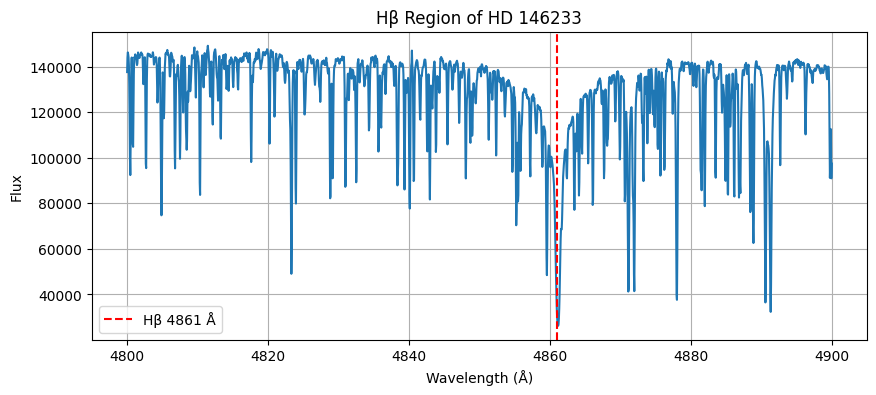

In [95]:
plt.figure(figsize=(10,4))

plt.plot(hb_wavelength, hb_flux)

plt.axvline(4861, color="red", linestyle="--", label="Hβ 4861 Å")

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

plt.title("Hβ Region of HD 146233")

plt.legend()
plt.grid(True)

plt.show()

## 7. Continuum Normalization of Hβ Region

The extracted Hβ region contains the absorption line and the surrounding
stellar continuum.

A preliminary continuum estimate was obtained by identifying the upper
flux level of the spectrum and scaling the Hβ profile.

The normalized spectrum is obtained by dividing the observed flux by the
estimated continuum level:

F(λ)/Fc

The final continuum normalization using polynomial fitting with selected
continuum windows (4750–4810 Å and 4920–4950 Å) will be applied for the
final line profile analysis.

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# Estimate continuum using upper percentile smoothing
continuum = np.percentile(hb_flux, 95)

# Normalize flux
hb_flux_norm = hb_flux / continuum


print("Estimated continuum:")
print(continuum)

print("Normalized flux range:")
print(hb_flux_norm.min(), hb_flux_norm.max())

Estimated continuum:
144932.33
Normalized flux range:
0.18113597 1.0296178


### Normalized Hβ Profile

The normalized Hβ absorption profile is shown below.

The continuum level has been scaled to approximately unity, allowing the
line depth and shape to be compared independently of the original flux
calibration.

The vertical dashed line represents the theoretical Hβ wavelength at
4861 Å.

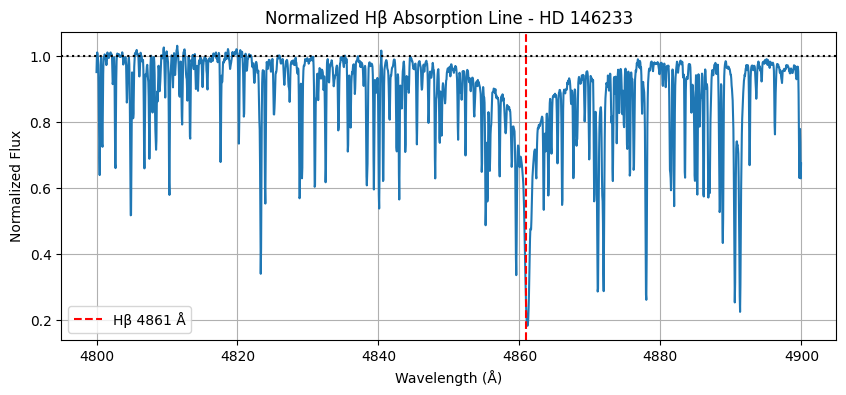

In [97]:
plt.figure(figsize=(10,4))

plt.plot(hb_wavelength, hb_flux_norm)

plt.axvline(4861, color="red", linestyle="--", label="Hβ 4861 Å")

plt.axhline(1.0, color="black", linestyle=":")

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title("Normalized Hβ Absorption Line - HD 146233")

plt.legend()
plt.grid(True)

plt.show()

## 7.1 Normalized Hβ Line Verification

The Hβ absorption line was successfully isolated and normalized.

After normalization, the continuum level is approximately equal to 1, while the absorption feature remains below the continuum level.

This normalized Hβ profile will be used later for comparison with synthetic PHOENIX spectra and stellar parameter fitting.

## 8. Saving Prepared Hβ Spectrum

The normalized Hβ spectrum was saved as a processed data file.

This allows later fitting steps to directly use the prepared observed spectrum without repeating the extraction and normalization process.

In [98]:
import numpy as np

output_path = "../data/observed/ELODIE/HD146233_Hbeta_normalized.txt"

np.savetxt(
    output_path,
    np.column_stack([hb_wavelength, hb_flux_norm]),
    header="Wavelength_Angstrom  Normalized_Flux"
)

print("Saved:", output_path)

Saved: ../data/observed/ELODIE/HD146233_Hbeta_normalized.txt


# 9. Radial Velocity Correction

The observed spectrum is affected by the radial motion of the star relative to the observer.

The heliocentric radial velocity of HD 146233 was obtained from the SIMBAD database.

Radial velocity:

vr = 11.764 km/s

The observed wavelength array was shifted to the stellar rest frame using:

λrest = λobs / (1 + vr/c)

where:

- λrest is the rest-frame wavelength.
- λobs is the observed wavelength.
- vr is the heliocentric radial velocity.
- c is the speed of light.

In [99]:
import numpy as np

# Radial velocity from SIMBAD
vr = 11.764  # km/s

# Speed of light
c = 299792.458  # km/s

# Apply radial velocity correction
wavelength_rest = wavelength / (1 + vr/c)

print("Observed wavelength range:")
print(wavelength[0], wavelength[-1])

print("\nRest-frame wavelength range:")
print(wavelength_rest[0], wavelength_rest[-1])

Observed wavelength range:
4000.0 6799.9500391993

Rest-frame wavelength range:
3999.8430442383833 6799.683216364961


### Verification of Hβ Rest-Frame Position

After applying the heliocentric radial velocity correction, the Hβ absorption
core position was measured in the rest-frame spectrum.

The measured wavelength was compared with the laboratory Hβ wavelength:

λ₀ = 4861.33 Å

A close agreement confirms that the radial velocity correction was successfully applied.

In [100]:
# Extract rest-frame Hβ region

hb_mask_rest = (
    (wavelength_rest >= 4800) &
    (wavelength_rest <= 4900)
)

hb_wave_rest = wavelength_rest[hb_mask_rest]
hb_flux_rest = flux[hb_mask_rest]


# Find minimum flux position (absorption core)

hb_core_index = np.argmin(hb_flux_rest)

hb_core_wavelength = hb_wave_rest[hb_core_index]


print("Hβ absorption core wavelength:")
print(hb_core_wavelength)

print("Expected Hβ wavelength:")
print(4861.33)

Hβ absorption core wavelength:
4860.959265680481
Expected Hβ wavelength:
4861.33


## 10. Continuum Normalization

To compare the observed Hβ line with synthetic PHOENIX spectra, the continuum around the absorption feature must be normalized.

Following the project instructions, the wavelength region from **4750 Å to 4950 Å** was extracted.

The continuum was estimated by fitting a low-order polynomial to the continuum regions:

- 4750–4810 Å
- 4920–4950 Å

The observed spectrum was then divided by the fitted continuum to obtain the normalized Hβ line profile.

In [101]:
# Extract the region required by the project

mask = (wavelength_rest >= 4750) & (wavelength_rest <= 4950)

wave = wavelength_rest[mask]
flux_region = flux[mask]

print("Wavelength range:")
print(wave[0], wave[-1])

print("Number of pixels:")
print(len(wave))

Wavelength range:
4750.01361768768 4949.955774660736
Number of pixels:
4000


# Select continuum regions

left_mask = (wave >= 4750) & (wave <= 4810)
right_mask = (wave >= 4920) & (wave <= 4950)

continuum_wave = np.concatenate([
    wave[left_mask],
    wave[right_mask]
])

continuum_flux = np.concatenate([
    flux_region[left_mask],
    flux_region[right_mask]
])

print("Left continuum pixels:", np.sum(left_mask))
print("Right continuum pixels:", np.sum(right_mask))
print("Total continuum pixels:", len(continuum_wave))

In [102]:
# Select continuum regions

left_mask = (wave >= 4750) & (wave <= 4810)
right_mask = (wave >= 4920) & (wave <= 4950)

continuum_wave = np.concatenate([
    wave[left_mask],
    wave[right_mask]
])

continuum_flux = np.concatenate([
    flux_region[left_mask],
    flux_region[right_mask]
])

print("Left continuum pixels:", np.sum(left_mask))
print("Right continuum pixels:", np.sum(right_mask))
print("Total continuum pixels:", len(continuum_wave))

Left continuum pixels: 1200
Right continuum pixels: 600
Total continuum pixels: 1800


### 10.1 Polynomial Continuum Fitting

The continuum was estimated by fitting a first-degree polynomial to the continuum regions on either side of the Hβ absorption line.

The fitted continuum was then used to normalize the observed spectrum by dividing the observed flux by the continuum model.

In [103]:
# Fit a first-degree polynomial to the continuum

coeff = np.polyfit(
    continuum_wave,
    continuum_flux,
    deg=1
)

continuum_fit = np.polyval(coeff, wave)

print("Polynomial coefficients:")
print(coeff)

Polynomial coefficients:
[-3.11289757e+01  2.83109298e+05]


### Continuum Normalization

The observed Hβ spectrum was normalized by dividing the extracted flux by the fitted continuum model.

This removes the overall continuum shape and leaves only the relative absorption line profile:

\[
F_{normalized}(\lambda)=\frac{F(\lambda)}{F_c(\lambda)}
\]

The normalized spectrum will have a continuum level close to 1.

In [104]:
# Normalize the spectrum

flux_normalized = flux_region / continuum_fit

print("Normalized flux range:")
print(np.min(flux_normalized))
print(np.max(flux_normalized))

Normalized flux range:
0.1991952050763452
1.1208756626855838


### Normalized Hβ Line Profile

The continuum-normalized Hβ absorption profile is shown below.

After normalization, the surrounding continuum should be approximately equal to 1,
allowing comparison with synthetic PHOENIX spectra.

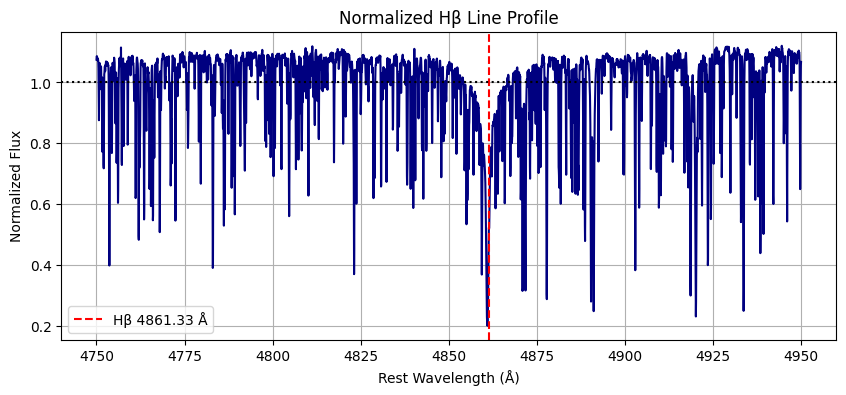

In [105]:
plt.figure(figsize=(10,4))

plt.plot(wave, flux_normalized, color="navy")

plt.axvline(
    4861.33,
    color="red",
    linestyle="--",
    label="Hβ 4861.33 Å"
)

plt.axhline(
    1.0,
    color="black",
    linestyle=":"
)

plt.xlabel("Rest Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title("Normalized Hβ Line Profile")

plt.grid(True)
plt.legend()

plt.show()

## 11. Uncertainty Estimation

The ELODIE FITS file provides a dedicated **NOISE** extension containing the per-pixel uncertainty of the observed spectrum.

Following the project instructions, this noise array was extracted directly from the FITS file instead of estimating the uncertainty from the continuum.

In [106]:
# Extract the uncertainty (noise) array

noise = hdul[2].data

print("Noise array length:")
print(len(noise))

print("\nMinimum noise:")
print(np.min(noise))

print("\nMaximum noise:")
print(np.max(noise))

Noise array length:
56000

Minimum noise:
nan

Maximum noise:
nan


### Noise Array Quality Check

Before using the uncertainty array in the Hβ fitting region, the data quality was checked.

The noise extension contains some invalid (NaN) values, so the number of NaN pixels and valid finite pixels was calculated.

In [107]:
import numpy as np

print("Total pixels:", len(noise))
print("Number of NaNs:", np.isnan(noise).sum())
print("Number of finite values:", np.isfinite(noise).sum())

Total pixels: 56000
Number of NaNs: 98
Number of finite values: 55902


### Noise Statistics

The uncertainty values were summarized using the valid (non-NaN) pixels only.

The minimum, maximum, and mean noise values provide an overview of the uncertainty level across the observed spectrum.

In [108]:
print("Minimum noise:", np.nanmin(noise))
print("Maximum noise:", np.nanmax(noise))
print("Mean noise:", np.nanmean(noise))

Minimum noise: 148.35178
Maximum noise: 3048.2292
Mean noise: 648.852


### Hβ Region Selection for Uncertainty

The uncertainty array was restricted to the same wavelength range used for the Hβ spectral analysis.

The selected region is:

4750 Å ≤ λ ≤ 4950 Å

This ensures that the uncertainty array corresponds exactly to the normalized Hβ line profile used for fitting.

In [109]:
# Define Hβ region

hb_mask = (
    (wavelength_rest >= 4750) &
    (wavelength_rest <= 4950)
)

print("Hβ pixels:")
print(np.sum(hb_mask))

Hβ pixels:
4000


### Extracting Hβ Region Uncertainty

The uncertainty array was filtered using the Hβ wavelength mask to obtain the per-pixel uncertainty values corresponding to the 4750–4950 Å fitting region.

These uncertainty values will be used to construct the final normalized uncertainty profile.

In [110]:
# Extract Hβ noise

hb_noise = noise[hb_mask]

print("Hβ noise pixels:")
print(len(hb_noise))

Hβ noise pixels:
4000


### Handling Invalid Uncertainty Values

The ELODIE NOISE extension contains a small number of invalid NaN values.

To avoid problems during later fitting, these invalid uncertainty values were replaced with the median uncertainty value calculated from the valid pixels.

This preserves the overall uncertainty level without introducing artificial variations.

In [111]:
# Replace NaN values with median uncertainty

hb_noise_clean = np.where(
    np.isfinite(hb_noise),
    hb_noise,
    np.nanmedian(hb_noise)
)

print("NaN after cleaning:")
print(np.isnan(hb_noise_clean).sum())

NaN after cleaning:
0


### Variable Verification

The existence of the extracted uncertainty arrays was checked before proceeding to the final uncertainty normalization step.

In [112]:
print("noise exists:", 'hb_noise' in globals())
print("noise_norm exists:", 'hb_noise_norm' in globals())

noise exists: True
noise_norm exists: True


### Normalizing the Uncertainty Array

The uncertainty values were converted into normalized uncertainties by dividing the per-pixel noise by the fitted continuum level.

This produces an uncertainty array consistent with the normalized Hβ flux profile:

\[
\sigma_{norm}(\lambda)=\frac{\sigma(\lambda)}{F_c(\lambda)}
\]

In [113]:
# Replace invalid noise values

hb_noise_clean = np.where(
    np.isfinite(hb_noise),
    hb_noise,
    np.nanmedian(hb_noise)
)


# Continuum already corresponds to the Hβ region

hb_continuum = continuum_fit


# Normalize uncertainty

hb_noise_norm = hb_noise_clean / hb_continuum


print("Noise pixels:", len(hb_noise_norm))
print("Minimum:", np.min(hb_noise_norm))
print("Maximum:", np.max(hb_noise_norm))

Noise pixels: 4000
Minimum: 0.002260036182108429
Maximum: 0.007045028376505786


### Final Hβ Uncertainty Array Check

The wavelength array and normalized uncertainty array were checked to ensure that both contain the same number of pixels.

This confirms that each wavelength point has a corresponding uncertainty value for later spectral fitting.

In [114]:
# Hβ wavelength array for final analysis
hb_wavelength = wavelength_rest[hb_mask]

print(len(hb_wavelength))
print(len(hb_noise_norm))

4000
4000


### Normalized Hβ Uncertainty Profile

The normalized uncertainty array was plotted across the Hβ wavelength region.

This visualization confirms that the uncertainty values are available for each wavelength pixel and can be used during the spectral line profile fitting.

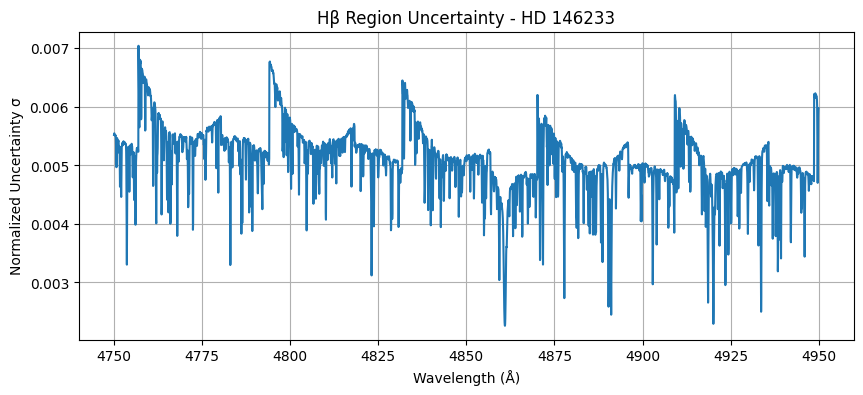

In [115]:
plt.figure(figsize=(10,4))

plt.plot(
    hb_wavelength,
    hb_noise_norm
)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Uncertainty σ")

plt.title("Hβ Region Uncertainty - HD 146233")

plt.grid(True)

plt.show()

## Uncertainty Estimation

The ELODIE FITS file provides a dedicated noise extension containing the
per-pixel instrumental uncertainty.

The noise array was extracted from the FITS extension:

hdul[2]

The Hβ region (4750–4950 Å) was selected using the same wavelength mask
as the normalized spectrum.

A small number of invalid NaN values were present in the noise array.
These pixels were replaced using the median value of the valid uncertainty
pixels.

The uncertainty values were normalized using the fitted continuum level:

\[
\sigma_{norm}(\lambda)=\frac{\sigma(\lambda)}{F_c(\lambda)}
\]

The final normalized uncertainty array represents the statistical uncertainty
associated with each wavelength pixel during spectral line profile fitting.

No smoothing or interpolation was applied to preserve the original spectral
line profile.

In [1]:
from astropy.io import fits

obs_path = "../data/observed/ELODIE/elodie_20000327_0030.fits"

hdul = fits.open(obs_path)

hdul.info()

Filename: ../data/observed/ELODIE/elodie_20000327_0030.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  INTENSITY     1 PrimaryHDU     109   (56000,)   float32   
  1  FCANOR        1 BinTableHDU     25   147R x 1C   [1E]   
  2  NOISE         1 ImageHDU       106   (56000,)   float32   


In [2]:
for i in range(len(hdul)):
    print(f"\n===== HDU {i} =====")
    print(hdul[i].header)


===== HDU 0 =====
SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -32 / No.Bits per pixel                              NAXIS   =                    1 / number of data axes                            NAXIS1  =                56000 / length of data axis 1                          EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astroph

In [3]:
for key, value in hdul[0].header.items():
    print(key, ":", value)

SIMPLE : True
BITPIX : -32
NAXIS : 1
NAXIS1 : 56000
EXTEND : True
COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT :   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT :   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT :   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT :   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
CRPIX1 : 1.0
CRVAL1 : 4000.0
CDELT1 : 0.0500000007
VERSION : 1.3
LASTCOMP : tacos_SunOS_5.4 - Thu Mar 7 14:46:32 WET 1996
INSTRUME : ELODIE
ORIGIN : OHP
CUMUL : 1.0
DATETU : 20000328
HDEBUT : 1.87889385
HFIN : 2.4625082
EXPTIME : 2101.12012
TIME1 : 2000.0
TIME2 : 3.0
TIME3 

In [4]:
lambda_hbeta = 4861.33  # Angstrom

delta_lambda = 0.1321429  # from FITS header

R = lambda_hbeta / delta_lambda

print("Instrument resolution R =", R)

Instrument resolution R = 36788.43131186011
